# Coffee Quality prediction

We solve a binary classification problem: specialty (>=80, class 0) vs below-specialty (<80 points, class 1). Our coffee dataset with 86/14 split has a moderate imbalance, so we use stratified data splitting, in order to have the same ratio in our training and testing sets. We will optimize the model based on precision, recall and the F1-score.

A ML model with high false positives classifies specialty coffee as below-specialty coffee and a model with high false negative, on the other hand, would classify below-specialty coffee as specialty coffee. To protect farmers of losing money on coffee that genuinely earned the premium price, we want a model with high precision on class 1, meaning only classifies a coffee as below-specialty when it is confident. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
from data_train import cup_score_class, train_logistic_regression, evaluate_at_seed
from data_train import train_random_forest, train_xgb_model, plot_precision_recall_vs_threshold
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

RANDOM_STATE = 42
project_root = Path.cwd().parent

%load_ext autoreload
%autoreload 2

# Dataset

We have 1296 coffee samples with 8 selected features: variety, processing_method, moisture, defect counts, color, and altitude.
The target variable is `Total.Cup.Points`.

In [2]:
coffe_data_path = project_root / "data" / "cleaned_coffee_data.csv"   
df = pd.read_csv(coffe_data_path)
X = df.drop(columns= "Total.Cup.Points").copy()
y = df["Total.Cup.Points"].copy()
y = y.apply(cup_score_class)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (1296, 8)
y shape: (1296,)


,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,Variety,Processing.Method,Color
0,2075.0,0.12,0,0,0.0,NaN,Washed / Wet,Green
1,2075.0,0.12,0,1,0.0,Other,Washed / Wet,Green
2,1700.0,0.00,0,0,0.0,Bourbon,NaN,NaN
3,2000.0,0.11,0,2,0.0,NaN,Natural / Dry,Green
4,2075.0,0.12,0,2,0.0,Other,Washed / Wet,Green


Total.Cup.Points
0    1118
1     178
Name: count, dtype: int64

Percentages:
Total.Cup.Points
0    86.3
1    13.7
Name: proportion, dtype: float64


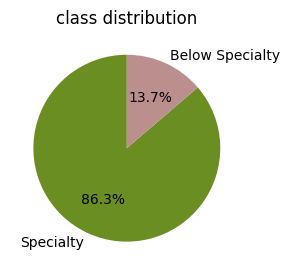

In [3]:
print(y.value_counts())
print(f"\nPercentages:")
print((y.value_counts(normalize=True)*100).round(1))

class_counts = y.value_counts()
plt.figure(figsize=(3, 3))
plt.pie(class_counts,labels=["Specialty", "Below Specialty",], autopct='%1.1f%%', 
    startangle=90,colors = ['olivedrab', 'rosybrown'])
plt.title("class distribution")
plt.tight_layout()
plt.show()

# Splitting the Dataset

We proceed to split the dataset by keeping the same ratio (SPecialty/Below Specialty) in both datasets setting 'stratify =y'. 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, 
                            random_state=RANDOM_STATE, stratify =y)
print(f"tran sample: {X_train.shape}, test samples: {X_test.shape}")

tran sample: (1036, 8), test samples: (260, 8)


## Feature Engineering

To fill the missing values in some of the features, we employed three strategies. For the numerical features: altitude_mean_meters and Moisture, we replaced the missing values with the median because it is robust for skewed distributions. Defect counts,are filled with 0 since a missing defect most likely means no defects were recorded. Finally, categorical nulls become 'Unknown', preserving missingness as a category rather than discarding those rows. 
max_categories=10 was set on the OneHotEncoder applied to the 'Variety' feature (28 unique values) to prevent high dimensionality.

In [6]:

median_num_features = ["altitude_mean_meters", "Moisture"]
zero_num_features = ["Category.One.Defects", "Category.Two.Defects", "Quakers"]
categorical_features = ["Variety", "Processing.Method", "Color"]

median_numerical_pipeline = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

zero_numerical_pipeline = Pipeline([
    ("impute_zero", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute_unknown", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False,max_categories=10)),
])

preprocessor = ColumnTransformer([
    ("num_median", median_numerical_pipeline, median_num_features),
    ("num_zero", zero_numerical_pipeline, zero_num_features),
    ("categorical", categorical_pipeline, categorical_features )
])

# Model building

The results shown below for each model belong to a single fixed train/test split. Since the below-specialty class has very few samples and considering that the non-sensory features only correlate weakly with the cupping score, the model's performance metrics on a given split would be a bit noisy. At the end of the notebook, we check the split sensitivity, re-running the same pipelines across 20 different splits to see how stable these results actually are.


## Logistic Regression 

For Logistic Regression we apply hyperparameter tuning to search for the optimal regularization parameter C (the default is set to C=1) to avoid overfitting.

In [7]:

param_grid = {'lr__C': [0.001, 0.01, 0.05, 0.1, 1]}

best_lr_grid = train_logistic_regression(preprocessor, X_train, y_train,random_state=RANDOM_STATE,param_grid=param_grid)
print(f"Best grid parameters: {best_lr_grid.best_params_}")

lr_model = best_lr_grid.best_estimator_
y_test_pred_lr = lr_model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred_lr))
print(classification_report(y_test, y_test_pred_lr, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Best grid parameters: {'lr__C': 0.05}
[[167  57]
 [ 14  22]]
                     precision    recall  f1-score   support

      Specialty (0)      0.923     0.746     0.825       224
Below Specialty (1)      0.278     0.611     0.383        36

           accuracy                          0.727       260
          macro avg      0.601     0.678     0.604       260
       weighted avg      0.833     0.727     0.763       260



The precision for below-specialty is low as expected. A low precision means that when the model predicts a coffee is below specialty, it is right only 30% of the time, while the remaining 70% of those predictions are false positives that missclasify actual specialty coffee.

## Precision and recall vs Threshold

To make a final decision, the model uses a classification threshold (by default set to 0.5). If the probability is above the threshold, it predicts class 1; if it is below, it predicts class 0. Accodingly, precision and recall will be defined based on the threshold values. By moving the threshold up or down, we can directly control the balance between precision and recall. 

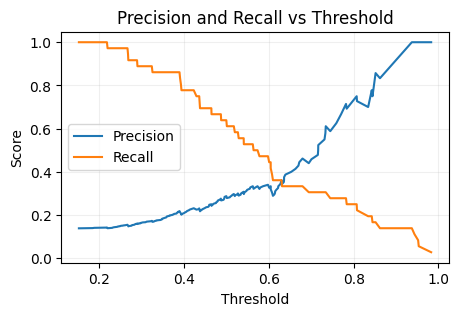

In [8]:
y_test_probs = lr_model.predict_proba(X_test)[:, 1]
plot_precision_recall_vs_threshold(y_test, y_test_probs)

By increasing the threshold we could increase precision and reduce False positives. 

# Random Forest Classifier



In [9]:

param_grid = {
        "rf__n_estimators": [100, 200, 300],
        "rf__max_features": ['sqrt', 0.3, 0.5],
        "rf__min_samples_leaf": [2, 3, 5, 7],
        "rf__max_depth": [None, 2, 3],
    }

rf_grid_search = train_random_forest(preprocessor, X_train, y_train, 
                                random_state=RANDOM_STATE, class_weight = 'balanced',param_grid=param_grid)
print(f"Best grid parameters: {rf_grid_search.best_params_}")
rf_forest_model = rf_grid_search.best_estimator_

y_test_pred_rf = rf_forest_model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best grid parameters: {'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 7, 'rf__n_estimators': 300}
[[179  45]
 [ 14  22]]
                     precision    recall  f1-score   support

      Specialty (0)      0.927     0.799     0.859       224
Below Specialty (1)      0.328     0.611     0.427        36

           accuracy                          0.773       260
          macro avg      0.628     0.705     0.643       260
       weighted avg      0.845     0.773     0.799       260



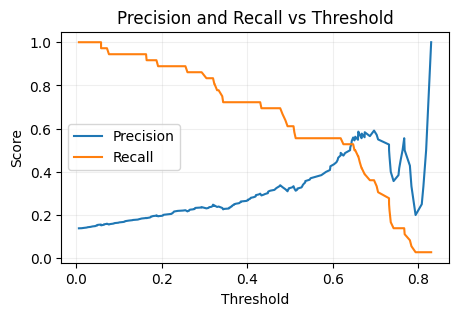

In [10]:
y_test_probs = rf_forest_model.predict_proba(X_test)[:, 1]
plot_precision_recall_vs_threshold(y_test, y_test_probs)

# XGBoost Classifier



In [11]:
param_grid = {
    'xgb__n_estimators': [30, 50, 70, 90],
    'xgb__max_depth': [2, 3, 4, 5, 6],
    'xgb__min_child_weight': [7, 9, 11, 13, 15]
}

grid_xgb = train_xgb_model(preprocessor, X_train, y_train, scoring='average_precision', 
                    random_state=RANDOM_STATE, param_grid=param_grid)

xgb_model = grid_xgb.best_estimator_
print(f"Best XGBoost Parameters: {grid_xgb.best_params_}")

y_test_pred_xgb = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred_xgb))
print(classification_report(y_test, y_test_pred_xgb, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Best XGBoost Parameters: {'xgb__max_depth': 4, 'xgb__min_child_weight': 9, 'xgb__n_estimators': 30}
[[159  65]
 [ 12  24]]
                     precision    recall  f1-score   support

      Specialty (0)      0.930     0.710     0.805       224
Below Specialty (1)      0.270     0.667     0.384        36

           accuracy                          0.704       260
          macro avg      0.600     0.688     0.595       260
       weighted avg      0.838     0.704     0.747       260



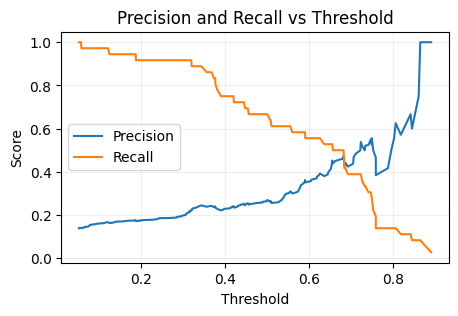

In [12]:
y_test_probs = xgb_model.predict_proba(X_test)[:, 1]
plot_precision_recall_vs_threshold(y_test, y_test_probs)

## Checking split sensitivity

In [18]:
seeds = range(20)
all_rows = [row for s in seeds for row in evaluate_at_seed(s, X, y, preprocessor)]
results_df = pd.DataFrame(all_rows)
summary = results_df.groupby("model")[["precision_1", "recall_1", "f1_1", "macro_f1"]].agg(["mean", "std"])
print(summary)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 5

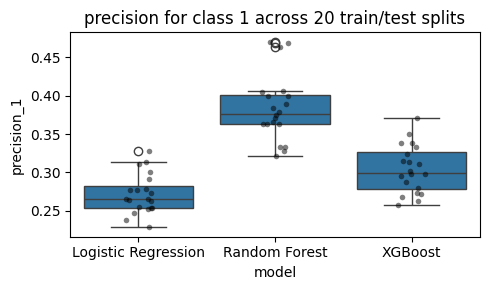

In [19]:

plt.figure(figsize=(5, 3))
sns.boxplot(data=results_df, x="model", y="precision_1")
sns.stripplot(data=results_df, x="model", y="precision_1", color="black", alpha=0.5, size=4)
plt.title("precision for class 1 across 20 train/test splits")
plt.tight_layout()
plt.show()

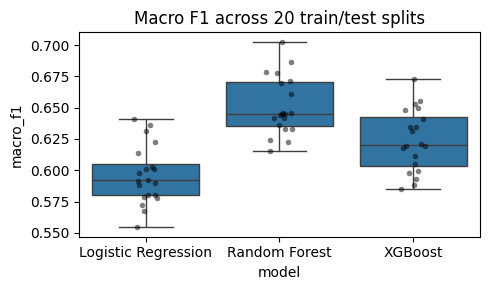

In [20]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=results_df, x="model", y="macro_f1")
sns.stripplot(data=results_df, x="model", y="macro_f1", color="black", alpha=0.5, size=4)
plt.title("Macro F1 across 20 train/test splits")
plt.tight_layout()
plt.show()


| Model | Precision (class 1) | Recall (class 1) | F1 Macro |
|---|---|---|---|
| Logistic Regression | 0.272 ± 0.026 | 0.610 ± 0.099  | 0.596 ± 0.023 |
| Random Forest       | 0.384 ± 0.044 | 0.444 ± 0.084 | 0.651 ± 0.023 |
| XGBoost             | 0.304 ± 0.031 | 0.615 ± 0.072 |  0.624 ± 0.025 |

All models struggle to identify below-specialty coffee, which is expected given the strong class imbalance and the weak correlation between non-sensory features and cupping score. Across 20 train/test splits, Random Forest wins as it gives a higher precision for class 1 and a higher overall macro F1 score. One could for instance increase precision even higher by threshold optimisation but it was not implemented here.



Given that none of the models exceeds 40% precision on the below-specialty class, none of these models are reliable enough to deploy for unsupervised coffee grading. Having more below-specialty data would definitely improve the model performance.